<a href="https://colab.research.google.com/github/shreya1110-dev/MTechCodeFiles/blob/main/Assignments/Sem1/DRL/Team_217_MAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part #1 - MAB: Adaptive Treatment Recommendation System

In [34]:
import numpy as np
import pandas as pd
import random
import math
import matplotlib.pyplot as plt

1. Dataset Creation Rules

In [13]:
GROUP_NUMBER = 217

random.seed(GROUP_NUMBER)
np.random.seed(GROUP_NUMBER)

1.1 Number of Medicines

In [14]:
K = (GROUP_NUMBER % 3) + 5

1.2 Hidden Success Probability

In [15]:
P = [0.4 + ((GROUP_NUMBER + i) % 6) * 0.07 for i in range(K)]

1.3 Patient Severity and Utility Logic

In [16]:
NUM_PATIENTS = 1000
patients_data = []

for patient_id in range(NUM_PATIENTS):
    severity_score = (patient_id % 5) + 1
    patients_data.append({
        'patient_id': patient_id,
        'severity_score': severity_score,
    })

df_patients = pd.DataFrame(patients_data)

In [17]:
def get_clinical_outcome_and_utility(assigned_medicine_idx, severity_score, hidden_probabilities):

    p_i = hidden_probabilities[assigned_medicine_idx]
    clinical_outcome = 1 if random.random() < p_i else 0

    utility_score = clinical_outcome * (1 - severity_score / 10)

    return clinical_outcome, utility_score


# Task 1: Dataset Design (1 Marks)

In [18]:
print(f"Group Number (G): {GROUP_NUMBER}")
print(f"Total Medicines (K): {K}")
print(f"Hidden Success Probabilities (P_i): {P}")

Group Number (G): 217
Total Medicines (K): 6
Hidden Success Probabilities (P_i): [0.47000000000000003, 0.54, 0.6100000000000001, 0.68, 0.75, 0.4]


In [19]:
df_patients.head(10)

,patient_id,severity_score
0,0,1
1,1,2
2,2,3
3,3,4
4,4,5
5,5,1
6,6,2
7,7,3
8,8,4
9,9,5


# Task 2: Immediate Exploitation Strategy (1 Marks)

In [20]:
df_immediate_exploitation = df_patients.copy()
total_rewards_per_medicine = [0.0] * K
num_trials_per_medicine = [0] * K
cumulative_rewards_immediate = []
INITIAL_TEST_ROUNDS = 10
initial_testing_patients = K * INITIAL_TEST_ROUNDS

In [21]:
print(f"Initial testing phase for the first {initial_testing_patients} patients (10 trials per medicine).")

for i in range(NUM_PATIENTS):
    patient_id = df_immediate_exploitation.loc[i, 'patient_id']
    severity_score = df_immediate_exploitation.loc[i, 'severity_score']

    assigned_medicine_idx = -1

    if i < initial_testing_patients:
        assigned_medicine_idx = i % K
    else:
        average_rewards = [
            total_rewards_per_medicine[j] / num_trials_per_medicine[j]
            if num_trials_per_medicine[j] > 0 else 0.0
            for j in range(K)
        ]
        assigned_medicine_idx = np.argmax(average_rewards)

    clinical_outcome, utility_score = get_clinical_outcome_and_utility(
        assigned_medicine_idx, severity_score, P
    )

    total_rewards_per_medicine[assigned_medicine_idx] += utility_score
    num_trials_per_medicine[assigned_medicine_idx] += 1

    df_immediate_exploitation.loc[i, 'assigned_medicine'] = assigned_medicine_idx
    df_immediate_exploitation.loc[i, 'clinical_outcome'] = clinical_outcome
    df_immediate_exploitation.loc[i, 'utility_score'] = utility_score

    if i == 0:
        cumulative_rewards_immediate.append(utility_score)
    else:
        cumulative_rewards_immediate.append(cumulative_rewards_immediate[-1] + utility_score)

print("Immediate Exploitation Strategy simulation complete.")

Initial testing phase for the first 60 patients (10 trials per medicine).
Immediate Exploitation Strategy simulation complete.


In [22]:
final_cumulative_reward_immediate = cumulative_rewards_immediate[-1]
print(f"Final Cumulative Reward (Immediate Exploitation): {final_cumulative_reward_immediate:.2f}")

print("\nFirst 10 rows of the dataset after Immediate Exploitation:")
display(df_immediate_exploitation.head(10))

Final Cumulative Reward (Immediate Exploitation): 460.00

First 10 rows of the dataset after Immediate Exploitation:


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0.0,0.0,0.0
1,1,2,1.0,1.0,0.8
2,2,3,2.0,1.0,0.7
3,3,4,3.0,1.0,0.6
4,4,5,4.0,1.0,0.5
5,5,1,5.0,1.0,0.9
6,6,2,0.0,1.0,0.8
7,7,3,1.0,0.0,0.0
8,8,4,2.0,1.0,0.6
9,9,5,3.0,1.0,0.5


### Task 3: Controlled Clinical Trial Strategy (1.5 Marks)

In [27]:
def run_controlled_clinical_trial_strategy(exploration_rate):
    df_cct = df_patients.copy()
    total_rewards_per_medicine_cct = [0.0] * K
    num_trials_per_medicine_cct = [0] * K
    cumulative_rewards_cct = []

    print(f"Controlled Clinical Trial Strategy with {exploration_rate*100}% exploration.")

    for i in range(NUM_PATIENTS):
        patient_id = df_cct.loc[i, 'patient_id']
        severity_score = df_cct.loc[i, 'severity_score']

        assigned_medicine_idx = -1

        if random.random() < exploration_rate:
            assigned_medicine_idx = random.randrange(K)
        else:
            average_rewards = [
                total_rewards_per_medicine_cct[j] / num_trials_per_medicine_cct[j]
                if num_trials_per_medicine_cct[j] > 0 else 0.0
                for j in range(K)
            ]
            assigned_medicine_idx = np.argmax(average_rewards)

        clinical_outcome, utility_score = get_clinical_outcome_and_utility(
            assigned_medicine_idx, severity_score, P
        )

        total_rewards_per_medicine_cct[assigned_medicine_idx] += utility_score
        num_trials_per_medicine_cct[assigned_medicine_idx] += 1

        df_cct.loc[i, 'assigned_medicine'] = assigned_medicine_idx
        df_cct.loc[i, 'clinical_outcome'] = clinical_outcome
        df_cct.loc[i, 'utility_score'] = utility_score

        if i == 0:
            cumulative_rewards_cct.append(utility_score)
        else:
            cumulative_rewards_cct.append(cumulative_rewards_cct[-1] + utility_score)

    print(f"Controlled Clinical Trial Strategy ({exploration_rate*100}% exploration) simulation complete.")
    final_cumulative_reward_cct = cumulative_rewards_cct[-1]
    print(f"Final Cumulative Reward (Controlled Clinical Trial, {exploration_rate*100}% Exploration): {final_cumulative_reward_cct:.2f}")

    return df_cct, cumulative_rewards_cct, final_cumulative_reward_cct

Running Controlled Clinical Trial Strategy with 10% Exploration

In [28]:
df_controlled_clinical_trial_10, cumulative_rewards_cct_10, final_cumulative_reward_cct_10 = run_controlled_clinical_trial_strategy(0.10)
display(df_controlled_clinical_trial_10.head(10))

Controlled Clinical Trial Strategy with 10.0% exploration.
Controlled Clinical Trial Strategy (10.0% exploration) simulation complete.
Final Cumulative Reward (Controlled Clinical Trial, 10.0% Exploration): 494.40


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0.0,0.0,0.0
1,1,2,0.0,0.0,0.0
2,2,3,0.0,1.0,0.7
3,3,4,0.0,1.0,0.6
4,4,5,5.0,1.0,0.5
5,5,1,5.0,1.0,0.9
6,6,2,3.0,0.0,0.0
7,7,3,5.0,1.0,0.7
8,8,4,5.0,0.0,0.0
9,9,5,5.0,1.0,0.5


Running Controlled Clinical Trial Strategy with 1% Exploration

In [29]:
df_controlled_clinical_trial_1, cumulative_rewards_cct_1, final_cumulative_reward_cct_1 = run_controlled_clinical_trial_strategy(0.01)
display(df_controlled_clinical_trial_1.head(10))

Controlled Clinical Trial Strategy with 1.0% exploration.
Controlled Clinical Trial Strategy (1.0% exploration) simulation complete.
Final Cumulative Reward (Controlled Clinical Trial, 1.0% Exploration): 406.90


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0.0,1.0,0.9
1,1,2,0.0,1.0,0.8
2,2,3,0.0,1.0,0.7
3,3,4,0.0,1.0,0.6
4,4,5,0.0,1.0,0.5
5,5,1,0.0,1.0,0.9
6,6,2,0.0,1.0,0.8
7,7,3,0.0,1.0,0.7
8,8,4,0.0,1.0,0.6
9,9,5,0.0,1.0,0.5


Running Controlled Clinical Trial Strategy with 50% Exploration

In [30]:
df_controlled_clinical_trial_50, cumulative_rewards_cct_50, final_cumulative_reward_cct_50 = run_controlled_clinical_trial_strategy(0.50)
display(df_controlled_clinical_trial_50.head(10))

Controlled Clinical Trial Strategy with 50.0% exploration.
Controlled Clinical Trial Strategy (50.0% exploration) simulation complete.
Final Cumulative Reward (Controlled Clinical Trial, 50.0% Exploration): 472.20


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0.0,0.0,0.0
1,1,2,3.0,1.0,0.8
2,2,3,3.0,1.0,0.7
3,3,4,0.0,1.0,0.6
4,4,5,2.0,1.0,0.5
5,5,1,0.0,1.0,0.9
6,6,2,5.0,1.0,0.8
7,7,3,5.0,0.0,0.0
8,8,4,3.0,0.0,0.0
9,9,5,0.0,0.0,0.0


### Task 4: Confidence-Based Strategy

In [32]:
def run_ucb1_strategy():
    df_ucb1 = df_patients.copy()
    total_rewards_per_medicine_ucb1 = [0.0] * K
    num_trials_per_medicine_ucb1 = [0] * K
    cumulative_rewards_ucb1 = []

    print("Running UCB1 Strategy.")

    for i in range(NUM_PATIENTS):
        patient_id = df_ucb1.loc[i, 'patient_id']
        severity_score = df_ucb1.loc[i, 'severity_score']

        assigned_medicine_idx = -1

        if i < K:
            assigned_medicine_idx = i % K
        else:
            ucb_values = []
            for j in range(K):
                if num_trials_per_medicine_ucb1[j] == 0:
                    ucb_values.append(float('inf')) #untried medicine
                else:
                    average_reward = total_rewards_per_medicine_ucb1[j] / num_trials_per_medicine_ucb1[j]
                    confidence_bound = math.sqrt(2 * math.log(i) / num_trials_per_medicine_ucb1[j])
                    ucb_values.append(average_reward + confidence_bound)
            assigned_medicine_idx = np.argmax(ucb_values)

        clinical_outcome, utility_score = get_clinical_outcome_and_utility(
            assigned_medicine_idx, severity_score, P
        )

        total_rewards_per_medicine_ucb1[assigned_medicine_idx] += utility_score
        num_trials_per_medicine_ucb1[assigned_medicine_idx] += 1

        df_ucb1.loc[i, 'assigned_medicine'] = assigned_medicine_idx
        df_ucb1.loc[i, 'clinical_outcome'] = clinical_outcome
        df_ucb1.loc[i, 'utility_score'] = utility_score

        if i == 0:
            cumulative_rewards_ucb1.append(utility_score)
        else:
            cumulative_rewards_ucb1.append(cumulative_rewards_ucb1[-1] + utility_score)

    print("UCB1 Strategy simulation complete.")
    final_cumulative_reward_ucb1 = cumulative_rewards_ucb1[-1]
    print(f"Final Cumulative Reward (UCB1 Strategy): {final_cumulative_reward_ucb1:.2f}")

    return df_ucb1, cumulative_rewards_ucb1, final_cumulative_reward_ucb1

In [33]:
df_ucb1, cumulative_rewards_ucb1, final_cumulative_reward_ucb1 = run_ucb1_strategy()
display(df_ucb1.head(10))

Running UCB1 Strategy.
UCB1 Strategy simulation complete.
Final Cumulative Reward (UCB1 Strategy): 440.50


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0.0,0.0,0.0
1,1,2,1.0,1.0,0.8
2,2,3,2.0,1.0,0.7
3,3,4,3.0,0.0,0.0
4,4,5,4.0,1.0,0.5
5,5,1,5.0,0.0,0.0
6,6,2,1.0,0.0,0.0
7,7,3,2.0,1.0,0.7
8,8,4,4.0,1.0,0.6
9,9,5,2.0,1.0,0.5


# Task 5: Comparative Analysis

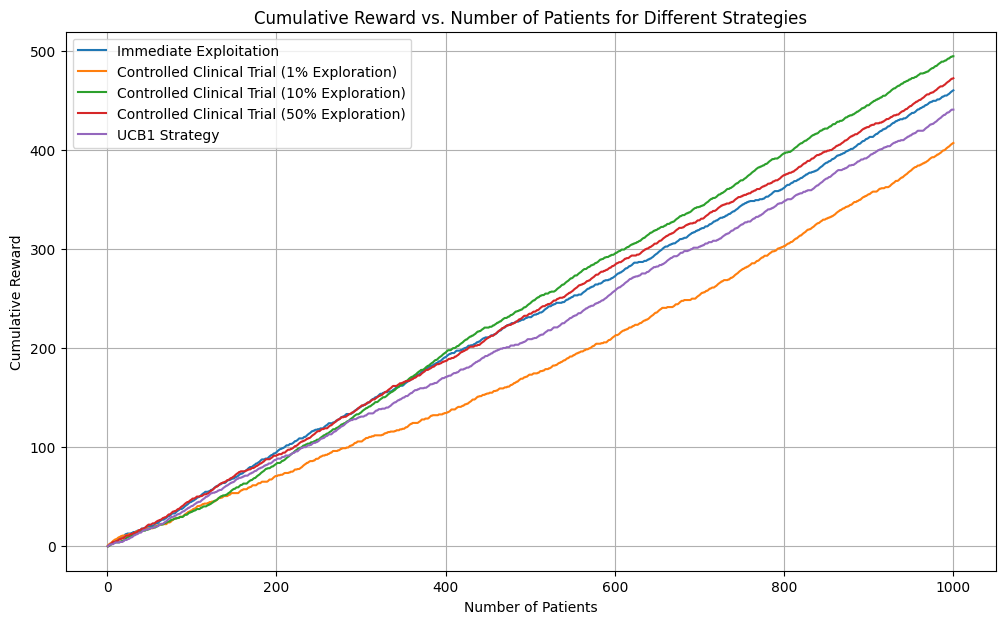

In [35]:
plt.figure(figsize=(12, 7))

plt.plot(range(1, NUM_PATIENTS + 1), cumulative_rewards_immediate, label='Immediate Exploitation')
plt.plot(range(1, NUM_PATIENTS + 1), cumulative_rewards_cct_1, label='Controlled Clinical Trial (1% Exploration)')
plt.plot(range(1, NUM_PATIENTS + 1), cumulative_rewards_cct_10, label='Controlled Clinical Trial (10% Exploration)')
plt.plot(range(1, NUM_PATIENTS + 1), cumulative_rewards_cct_50, label='Controlled Clinical Trial (50% Exploration)')
plt.plot(range(1, NUM_PATIENTS + 1), cumulative_rewards_ucb1, label='UCB1 Strategy')

plt.title('Cumulative Reward vs. Number of Patients for Different Strategies')
plt.xlabel('Number of Patients')
plt.ylabel('Cumulative Reward')
plt.legend()
plt.grid(True)
plt.show()

1. Highest cumulative reward: Controlled clinical trial with 10% Exploration</br>
2. Best medicine fastest: